# <span style="color:#336699">Aprendizado Supervisionado - KNN</span>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 90%;">
    Autor: <br/>
    Flávio Belizário da Silva Mota <br/>
    <br/>
</div>
</div>
O objetivo desde notebook é apresentar o classificador KNN para o curso de Sistemas de Informação.

### Importando as bibliotecas

Vamos importar as bibliotecas (módulos e submódulos) necessárias para rodar esse primeiro exemplo. A maior parte dos módulos vêm da própria `scikit-learn`.

É possível explorar os recursos da scikit a partir de sua documentação:

[Documentação da scikit](https://scikit-learn.org/stable/)

In [ ]:
# Importando as bibliotecas necessárias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import recall_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

### Carregando os dados

O módulo [`sklearn.datasets`](https://scikit-learn.org/stable/datasets.html) incorpora alguns pequenos conjuntos de dados. Este módulo também apresenta funções auxiliares para buscar conjuntos de dados maiores que são comumente utilizados pela comunidade de aprendizado de máquina.

In [ ]:
# Carregando o conjunto de dados Iris
iris = load_iris()

In [ ]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

Nós carregamos os dados do conjunto Iris. Este é um conjunto de dados famoso que contêm medidas de comprimento e largura das sépalas e pétalas de 150 flores de íris de três espécies diferentes: íris-Setosa, Íris-Versicolor e Íris-Virginica. Existem 50 amostras para cada uma das espécies.<br/>
<p><a href="https://commons.wikimedia.org/wiki/File:Flores_de_%C3%8Dris.png#/media/Ficheiro:Flores_de_Íris.png"><img src="https://upload.wikimedia.org/wikipedia/commons/c/cb/Flores_de_%C3%8Dris.png" alt="Flores de Íris.png" width="640" height="321"></a>
<br> Por <a href="//commons.wikimedia.org/wiki/User:Dcbmariano" title="User:Dcbmariano"&gt;Diego Mariano&lt;/a&gt; - &lt;span class="int-own-work" lang="pt"&gt;Obra do próprio&lt;/span&gt;, <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>, <a href="https://commons.wikimedia.org/w/index.php?curid=114511020">Wikipedia</a></p>

No contexto de aprendizado supervisionado, vimos que nossos conjuntos de dados contém amostras, atributos e rótulos. Uma prática comum em projetos de aprendizado de máquina com a scikit é colocar os dados (amostras + atributos) em uma matriz chamada **`X`** e os rótulos em outra matriz chamada **`y`**. Isso se deve a notação matemática de que f(X) = y, ou seja, com os dados que temos, nossos pontos no espaço X, queremos encontrar uma função (o modelo) que produz um rótulo, y.

In [ ]:
X = iris.data  # Características
y = iris.target # Rótulos (classes)

Vamos visualizar rapidamente o conjunto de dados, para termos uma noção de como ele se comporta no espaço. Por conter 4 dimensões, não conseguimos visualizar diretamente, por isso vamos escolher apenas 2 delas para exibir os dados:

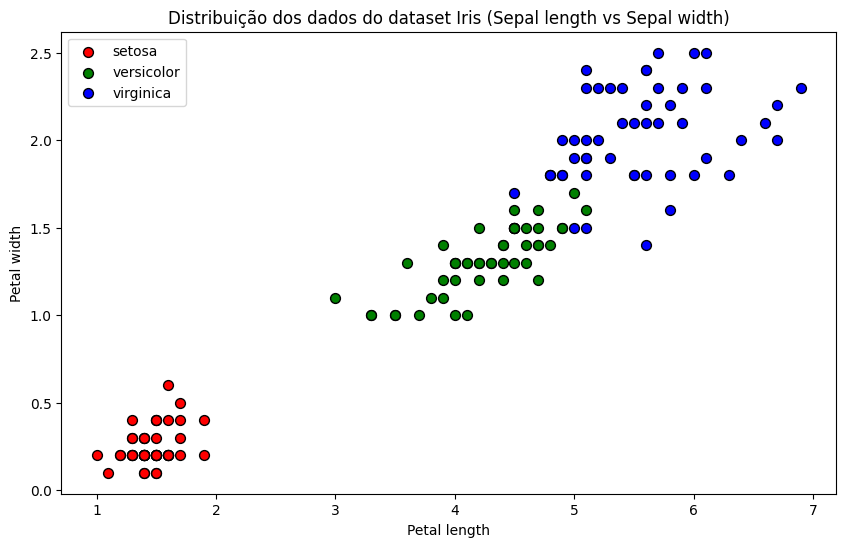

In [ ]:
# Visualizando os dados
# Paleta de cores e nomes das classes
colors = ['red', 'green', 'blue']
class_names = iris.target_names

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(class_names):
    plt.scatter(
        X[y == i, 2],  # Usando a primeira coluna de X
        X[y == i, 3],  # Usando a segunda coluna de X
        c=colors[i],
        edgecolors='k',
        s=50,
        label=class_name
    )

plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('Distribuição dos dados do dataset Iris (Sepal length vs Sepal width)')
plt.legend(loc='upper left')
plt.show()

Quais hipóteses vocês conseguem extrair dessa distrubuição? Descreva:

--- insira sua resposta aqui ---

### Dividindo o conjunto de dados

Treinar um modelo de aprendizado supervisionado significa apresentar para ele vários exemplos de dados de um problema (amostras) e deixar que ele encontre uma função que permita entender o padrão desses dados e, posteriormente, apresentar dados ainda não vistos pelo modelo, para que ele rotule automaticamente. A questão é: como sabemos se ele está aprendendo ou apenas "chutando muito bem"?

Para isso, utilizamos uma divisão no conjunto de dados para que eles sejam separados em conjuntos menores chamados de **treinamento e teste**.

O **conjunto de treinamento** é utilizado na etapa de treino do modelo. O **conjunto de teste** serve para que, após o treinamento, possamos medir o quanto o modelo acerta ou erra. A medição do acerto e dos erros é tópico para uma aula futura, vamos nos concentrar apenas no conceito de conjuntos de treinamento e teste.

Uma abordagem muito comum é separar 20% do conjunto de dados para ser utilizado no teste, uma regra chamada **80/20** (80% dos dados para treinar, 20% para testar). Sendo assim, o modelo vê uma quantidade maior do conjunto de dados na hora de aprender e usa uma quantidade menor para testar.


Para realizarmos essa divisão, podemos usar o método `train_test_split`:

In [ ]:
# Dividindo os dados em conjuntos de treinamento e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Qtde de amostras de treinamento:", len(X_train))
print("Qtde de amostras de teste:", len(X_test))

Qtde de amostras de treinamento: 120
Qtde de amostras de teste: 30


### Treinando o modelo

Vamos treinar um modelo KNN para classificar o conjunto de dados. Faremos isso estabelecendo uma vizinhança de 3 (k=3).

In [ ]:
# Inicializando o classificador KNN (escolhendo k=3 vizinhos)
knn = KNeighborsClassifier(n_neighbors=8, p=2)

Para treinar, usamos o método `fit()`, informando os dados e rótulos do **conjunto de treinamento**.

In [ ]:
# Treinando o modelo com os dados de treinamento
%time knn.fit(X_train, y_train)

CPU times: user 1.74 ms, sys: 1.06 ms, total: 2.8 ms
Wall time: 6.23 ms


KNeighborsClassifier(n_neighbors=8)

Após o treinamento, usando o método `fit()`, é possível pedir que o modelo ajustado faça previsões usando o método `predict()`. Nós faremos as previsões no conjunto de dados de teste, pois é a parcela do dado que o modelo ainda não viu.

In [ ]:
# Fazendo previsões no conjunto de teste
y_pred = knn.predict(X_test)

In [ ]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
y_test


array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

### Visualizando os resultados (e "medindo" o desempenho)

Depois de ter treinado o modelo e solicitado que ele fizesse previsões em dados ainda não vistos, podemos medir o quanto ele erra ou acerta e visualizar o resultado dessa classificação.

Para a visualização, vamos usar apenas 2 atributos, por conta da dimensionalidade do conjunto de dados.

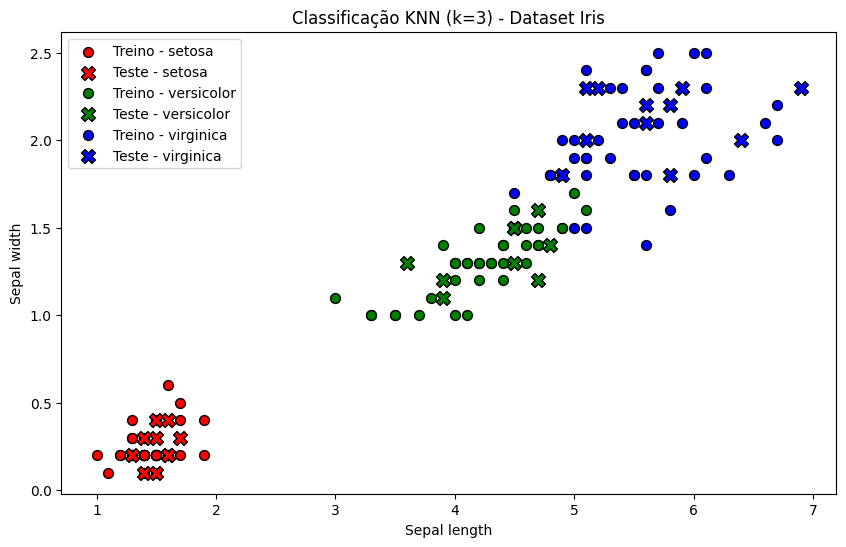

Acurácia: 1.00
F1: 1.00
Precisão: 1.00
Recall: 1.00


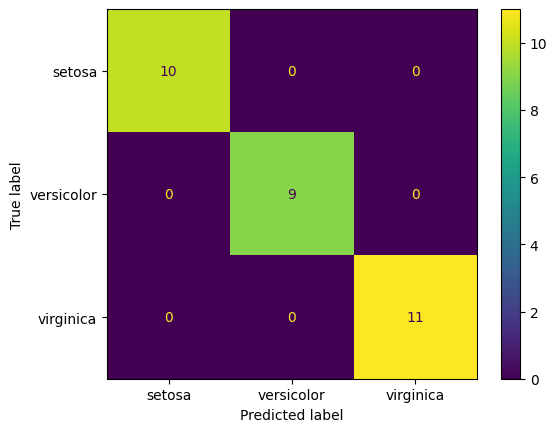

In [ ]:
# --- Visualização dos resultados ---
# Selecionando apenas as duas primeiras dimensões para exibição
X_train_vis = X_train[:, 2:]
X_test_vis = X_test[:, 2:]

# Paleta de cores e nomes das classes
colors = ['red', 'green', 'blue']
class_names = iris.target_names

plt.figure(figsize=(10, 6))

# Plotando os pontos de treino e teste com legendas organizadas
for i, class_name in enumerate(class_names):
    # Dados de treinamento
    plt.scatter(
        X_train_vis[y_train == i, 0],
        X_train_vis[y_train == i, 1],
        c=colors[i],
        edgecolors='k',
        s=50,
        label=f"Treino - {class_name}"
    )
    # Dados de teste
    plt.scatter(
        X_test_vis[y_test == i, 0],
        X_test_vis[y_test == i, 1],
        c=colors[i],
        marker='X',
        edgecolors='k',
        s=100,
        label=f"Teste - {class_name}"
    )

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Classificação KNN (k=3) - Dataset Iris')
plt.legend(loc='upper left')
plt.show()

# Mostrar a precisão do modelo
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print(f"F1: {f1_score(y_test, y_pred, average='weighted'):.2f}")
y_pred_proba = knn.predict_proba(X_test)
label_binarizer = LabelBinarizer()
y_test_one_hot = label_binarizer.fit_transform(y_test)
print(f"Precisão: {average_precision_score(y_test_one_hot, y_pred_proba, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.2f}")

matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=iris.target_names)
disp.plot()
plt.show()

A Acurácia 1.00 mede a proporção geral de acertos do modelo em relação ao total de previsões. Indicando 1 pois é o modelo padrão com todas as amostras iguais

F1-Score: É a média harmônica entre a Precisão e o Recall. Oferece um equilíbrio entre ambas, do mesmo modo em 1.00 pelo equilibrio

Precisão Average Precision: Avalia a qualidade das previsões positivas. Mede o quanto o modelo é confiável, 1.00, mesma história

Recall : Avalia a capacidade de detecção do modelo. Mede a proporção de flores de uma determinada classe que o modelo conseguiu identificar, 1.00, mesmo modelo

Matriz de Confusão: Exibe o detalhamento dos acertos e erros cruzando as classes reais com as previstas.
Setosa: 10 amostras reais de setosa foram previstas corretamente como setosa.   Versicolor: 9 amostras reais de versicolor foram previstas corretamente como versicolor.   
Virginica: 11 amostras reais de virginica foram previstas corretamente como virginica.
1.00 dnv



---

